# 9.2. MEG-fMRI Fusion: Temporal + Spatial Integration

**Learning Objectives:**
- Understand why MEG-fMRI fusion is useful for combining temporal and spatial precision
- Build separate MEG and fMRI feature pipelines, then integrate them for joint decoding
- Learn practical co-registration concepts required for MEG-fMRI analysis
- Compare unimodal vs multimodal performance under consistent cross-validation

**Key Concepts:**
- **Temporal + Spatial Integration**: MEG captures millisecond dynamics, fMRI captures fine spatial localization
- **Feature Fusion**: Combining modality-specific representations for a shared classifier
- **Co-registration**: Aligning MEG source/head coordinates with MRI/fMRI spaces
- **Evaluation Design**: Use consistent CV splits to compare unimodal and fused models fairly

This notebook mirrors the workflow from **9.1 EEG-fMRI fusion**, but uses MEG features (from MNE sample data) and fMRI features (from Haxby), then performs a didactic multimodal integration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.datasets import sample

from nilearn import datasets, image
from nilearn.input_data import NiftiMasker

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
mne.set_config('MNE_TQDM', 'off')

rng = np.random.RandomState(42)

/var/folders/4w/jb7nh9ns51vcx_1p3nn151800000gn/T/ipykernel_5067/2972350617.py:11: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


## 1. MEG Features (Temporal Information)

We use the MNE sample dataset and extract gradiometer MEG epoch features for **auditory vs visual** decoding.

To capture temporal information, we build multiple time-window features and concatenate them.

In [2]:
repo_root = Path("./").resolve().parents[1]
meg_dir = repo_root / "datasets" / "meg_sample"
meg_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(meg_dir), download=True)
meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / "MEG" / "sample" / "sample_audvis_raw-eve.fif"

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.pick_types(meg='grad', eeg=False, eog=False, stim=False)

event_id = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
}

epochs = mne.Epochs(
    raw, events, event_id,
    tmin=-0.2, tmax=0.5,
    baseline=(None, 0),
    preload=True,
    reject=dict(grad=4000e-13),
    decim=4,
)

epochs.events[:, 2] = (epochs.events[:, 2] >= 3).astype(int)
epochs.event_id = {'auditory': 0, 'visual': 1}

meg_data = epochs.get_data()  # (trials, channels, time)
meg_labels = epochs.events[:, 2]
times = epochs.times

# Multi-window temporal features
windows = [(-0.10, 0.00), (0.00, 0.10), (0.10, 0.20), (0.20, 0.35)]
feat_list = []
for t0, t1 in windows:
    m = (times >= t0) & (times <= t1)
    feat_list.append(meg_data[:, :, m].mean(axis=2))

X_meg = np.concatenate(feat_list, axis=1)  # (trials, channels * n_windows)

print("MEG feature shape:", X_meg.shape)
print("MEG class balance [auditory, visual]:", np.bincount(meg_labels))

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

NOTE: pick_types() is a legacy function

## 2. fMRI Features (Spatial Information)

As in 7.2, we use Haxby fMRI and extract VT-mask voxel features for **house vs face**.

In [3]:
fmri_dir = repo_root / "datasets" / "fmri_mvpa_haxby"
fmri_dir.mkdir(parents=True, exist_ok=True)

haxby = datasets.fetch_haxby(data_dir=str(fmri_dir))
fmri_img = image.load_img(haxby.func[0])
vt_mask_img = image.load_img(haxby.mask_vt[0])

labels_df = pd.read_csv(haxby.session_target[0], sep=" ")
labels = labels_df['labels'].values
is_face_house = np.isin(labels, ['face', 'house'])
fmri_labels = (labels[is_face_house] == 'face').astype(np.int64)  # house=0, face=1

from nilearn.image import index_img
fmri_sel = index_img(fmri_img, np.where(is_face_house)[0])

masker = NiftiMasker(mask_img=vt_mask_img, standardize=True, detrend=True)
X_fmri = masker.fit_transform(fmri_sel)

print("fMRI feature shape:", X_fmri.shape)
print("fMRI class balance [house, face]:", np.bincount(fmri_labels))

[fetch_haxby] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001
fMRI feature shape: (216, 464)
fMRI class balance [house, face]: [108 108]


## 3. Co-registration (Conceptual Checklist)

For real MEG-fMRI integration, co-registration is essential:
- Align MEG sensors/head coordinates using fiducials and digitization
- Align head coordinates to structural MRI
- Map MEG source estimates to cortical/MNI space
- Match fMRI ROIs/activations to the same anatomical coordinate system

In this tutorial we demonstrate **feature-level fusion** on paired vectors, but real studies should perform full source-space co-registration.

## 4. Build a Didactic Paired Dataset

As in 9.1, we construct a balanced paired subset (didactic setup) so we can run a clear unimodal-vs-fusion comparison using identical labels and CV splits.

In [4]:
def balanced_indices(y, n_per_class, random_state=42):
    rng_local = np.random.RandomState(random_state)
    i0 = np.where(y == 0)[0]
    i1 = np.where(y == 1)[0]
    rng_local.shuffle(i0)
    rng_local.shuffle(i1)
    idx = np.concatenate([i0[:n_per_class], i1[:n_per_class]])
    rng_local.shuffle(idx)
    return idx

n_common = min(np.bincount(meg_labels).min(), np.bincount(fmri_labels).min(), 100)

idx_meg = balanced_indices(meg_labels, n_common, random_state=42)
idx_fmri = balanced_indices(fmri_labels, n_common, random_state=42)

X_meg_pair = X_meg[idx_meg]
y_meg_pair = meg_labels[idx_meg]

X_fmri_pair = X_fmri[idx_fmri]
y_fmri_pair = fmri_labels[idx_fmri]

# Align by label ordering
ord_meg = np.argsort(y_meg_pair)
ord_fmri = np.argsort(y_fmri_pair)

X_meg_pair = X_meg_pair[ord_meg]
X_fmri_pair = X_fmri_pair[ord_fmri]
y_pair = np.sort(y_meg_pair)

print("Paired sample count:", len(y_pair))
print("Class balance [0,1]:", np.bincount(y_pair))
print("Paired MEG shape:", X_meg_pair.shape)
print("Paired fMRI shape:", X_fmri_pair.shape)

Paired sample count: 200
Class balance [0,1]: [100 100]
Paired MEG shape: (200, 812)
Paired fMRI shape: (200, 464)


## 5. Temporal + Spatial Feature Integration

We reduce each modality separately, then concatenate:
- MEG reduced features represent temporal dynamics
- fMRI reduced features represent spatial patterns
- fused vector combines both

In [5]:
n_meg_pca = min(30, X_meg_pair.shape[1])
n_fmri_pca = min(50, X_fmri_pair.shape[1])

pipe_meg = make_pipeline(StandardScaler(), PCA(n_components=n_meg_pca, random_state=42))
pipe_fmri = make_pipeline(StandardScaler(), PCA(n_components=n_fmri_pca, random_state=42))

X_meg_red = pipe_meg.fit_transform(X_meg_pair)
X_fmri_red = pipe_fmri.fit_transform(X_fmri_pair)
X_fused = np.hstack([X_meg_red, X_fmri_red])

print("Reduced MEG shape:", X_meg_red.shape)
print("Reduced fMRI shape:", X_fmri_red.shape)
print("Fused shape:", X_fused.shape)

Reduced MEG shape: (200, 30)
Reduced fMRI shape: (200, 50)
Fused shape: (200, 80)


## 6. Unimodal vs Fusion Comparison

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)

scores_meg = cross_val_score(clf, X_meg_red, y_pair, cv=cv, n_jobs=1)
scores_fmri = cross_val_score(clf, X_fmri_red, y_pair, cv=cv, n_jobs=1)
scores_fused = cross_val_score(clf, X_fused, y_pair, cv=cv, n_jobs=1)

print("MEG-only CV accuracy:", np.round(scores_meg, 3), "| mean=", round(scores_meg.mean(), 3))
print("fMRI-only CV accuracy:", np.round(scores_fmri, 3), "| mean=", round(scores_fmri.mean(), 3))
print("Fusion CV accuracy:", np.round(scores_fused, 3), "| mean=", round(scores_fused.mean(), 3))

MEG-only CV accuracy: [0.875 0.925 0.95  0.9   0.925] | mean= 0.915
fMRI-only CV accuracy: [1. 1. 1. 1. 1.] | mean= 1.0
Fusion CV accuracy: [1.    1.    0.975 1.    1.   ] | mean= 0.995


,Model,Mean Accuracy,Std
0,MEG-only,0.915,0.025495
1,fMRI-only,1.000,0.000000
2,MEG+fMRI Fusion,0.995,0.010000


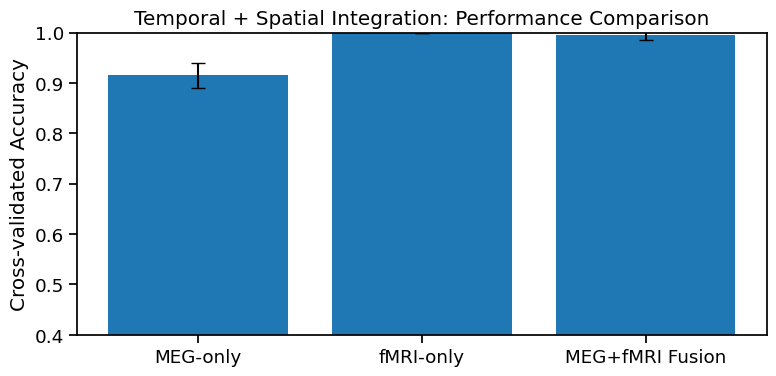

In [7]:
results = pd.DataFrame({
    'Model': ['MEG-only', 'fMRI-only', 'MEG+fMRI Fusion'],
    'Mean Accuracy': [scores_meg.mean(), scores_fmri.mean(), scores_fused.mean()],
    'Std': [scores_meg.std(), scores_fmri.std(), scores_fused.std()]
})
display(results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results['Model'], results['Mean Accuracy'], yerr=results['Std'], capsize=5)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Cross-validated Accuracy')
ax.set_title('Temporal + Spatial Integration: Performance Comparison')
plt.tight_layout()
plt.show()

## 7. Final Fusion Model Inspection

Confusion matrix (inspection):
[[100   0]
 [  0 100]]

Classification report:
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00       100
     class 1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



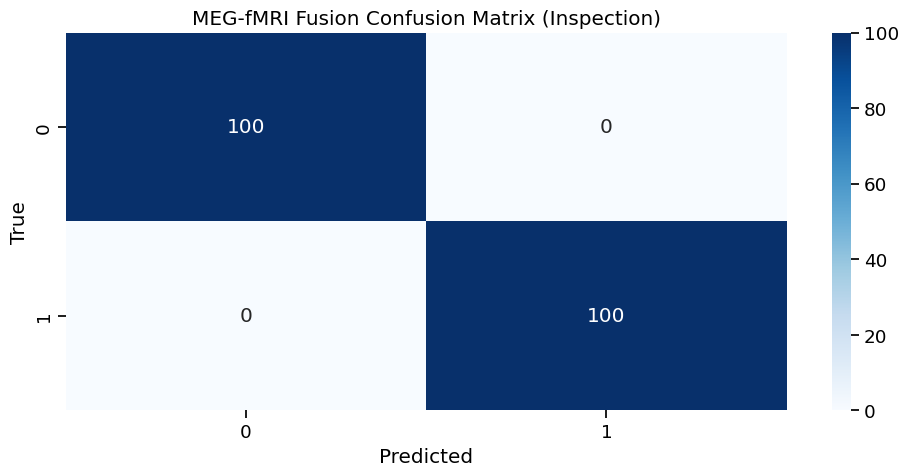

In [8]:
final_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)
final_clf.fit(X_fused, y_pair)
y_pred = final_clf.predict(X_fused)

cm = confusion_matrix(y_pair, y_pred)
print("Confusion matrix (inspection):")
print(cm)

print("\nClassification report:")
print(classification_report(y_pair, y_pred, target_names=['class 0', 'class 1']))

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('MEG-fMRI Fusion Confusion Matrix (Inspection)')
plt.tight_layout()
plt.show()

## 8. Summary and Practical Guidance

This notebook demonstrated a practical MEG-fMRI integration workflow:
- extracted temporal MEG features
- extracted spatial fMRI features
- fused both under a shared classifier and CV protocol

For real deployments:
- use simultaneous or properly matched MEG-fMRI datasets
- perform full source-space co-registration
- use subject/run-aware CV (`GroupKFold`, `LeaveOneGroupOut`)
- compare early fusion, late fusion, and deep multimodal fusion architectures

This forms the core template for temporal+spatial multimodal decoding experiments.